# **IAPR26: UNO Vision Challenge**


**Group Name :** 

**Author 1 (sciper):** Arno Douady (326395)  
**Author 2 (sciper):** Nicolas Robson (325334)   
**Author 3 (sciper):** Johanne Pinel (324707)   

**Release date:** 24.04.2026   
**Due date:** 20.05.2026 (11:55 pm)


In [1]:
# From past Labs

from skimage.color import rgb2hsv
from skimage.morphology import closing, opening, disk, remove_small_holes, remove_small_objects, binary_dilation
from skimage.transform import rotate, resize, AffineTransform, warp
from sklearn.metrics.pairwise import euclidean_distances
from skimage.measure import regionprops
import matplotlib.image as mpimg


import os
import copy
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from src.Project_utils import *

from sklearn.metrics import accuracy_score, f1_score

In [2]:
# Check dans quel dossier on est
print(os.getcwd())

c:\Users\Johanne\Desktop\EPFL\MA4\Image pattern\iapr2026\Project


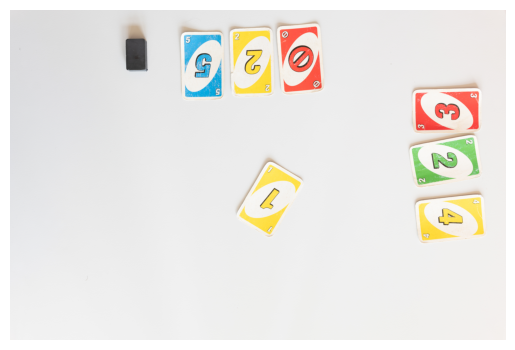

In [3]:
# Printer une image
img = mpimg.imread("data/iapr-26-uno-vision-challenge/train_images/L1000770.jpg")

plt.imshow(img)
plt.axis("off")
plt.show()

## Fist step : Segmentation

Extraire les cartes --> hmmm peut être faire 5 images : une pour le jaune, une pour le rouge, une pour le bleu et une pour le vert et une dernière pour le noir ?

In [4]:
def extract_hsv_channels(img):
    """
    Extract HSV channels from the input image.

    """
    # Get the shape of the input image
    M, N, C = np.shape(img)

    # Define default values for HSV channels
    data_h = np.zeros((M, N))
    data_s = np.zeros((M, N))
    data_v = np.zeros((M, N))

    data_hsv = rgb2hsv(img)
    data_h = data_hsv[:, :, 0]
    data_s = data_hsv[:, :, 1]
    data_v = data_hsv[:, :, 2]
    # print(np.min(data_h), np.max(data_h))
    # print(np.min(data_s), np.max(data_s))
    # print(np.min(data_v), np.max(data_v))
    
    return data_h, data_s, data_v

In [5]:
def apply_hsv_threshold(img, h_thresh=0.1, s_thresh=0.1, v_thesh=0.1):
    """
    Apply threshold to the input image in hsv colorspace.

    Args
    ----
    img: np.ndarray (M, N, C)
        Input image of shape MxN and C channels.
    h_thresh: float
        Hue value threshold
    s_thresh: float
        Saturation value threshold
    v_thresh: float
        Value threshold
    
    Return
    ------
    img_th: np.ndarray (M, N)
        Thresholded image.
    """

    # Define the default value for the input image
    M, N, C = np.shape(img)
    img_th = np.zeros((M, N))

    # Use the previous function to extract HSV channels
    data_h, data_s, data_v = extract_hsv_channels(img=img)
    
    # ------------------
    # Your code here ... 
    # ------------------
    img_th = (data_h > h_thresh) & (data_s > s_thresh) & (data_v > v_thesh)
    
    return  img_th

    

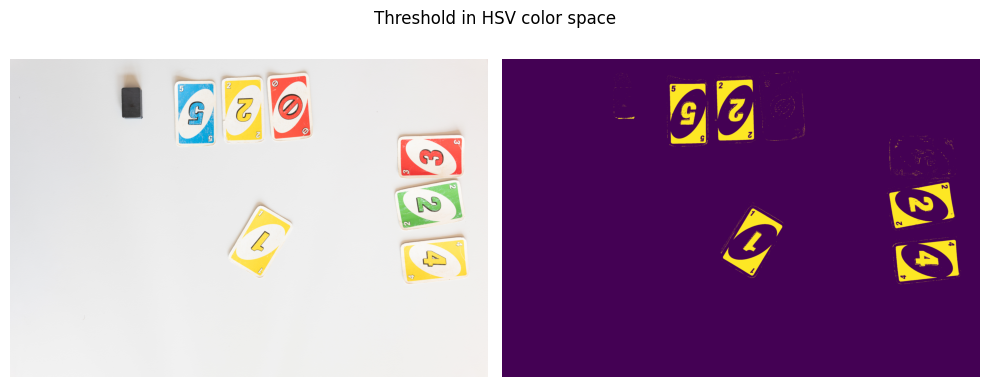

In [6]:
img_th=apply_hsv_threshold(img)
plot_thresholded_image(img=img, func=apply_hsv_threshold, title="Threshold in HSV color space")

Pas zinzin hsv j'arrive pas à faire les plots comme dans le tp ça run pendant mille ans

In [14]:
def extract_rgb_channels(img):
    """
    Extract RGB channels from the input image.

    Args
    ----
    img: np.ndarray (M, N, C)
        Input image of shape MxN and C channels.
    
    Return
    ------
    data_red: np.ndarray (M, N)
        Red channel of input image
    data_green: np.ndarray (M, N)
        Green channel of input image
    data_blue: np.ndarray (M, N)
        Blue channel of input image
    """

    # Get the shape of the input image
    M, N, _ = np.shape(img)

    # Define default values for RGB channels
    data_red = np.zeros((M, N))
    data_green = np.zeros((M, N))
    data_blue = np.zeros((M, N))

    # ------------------
    # Your code here ... 
    data_red = img[:, :, 0]
    data_green = img[:, :, 1]
    data_blue = img[:, :, 2]
    # ------------------
    
    return data_red, data_green, data_blue

In [ ]:
def apply_rgb_threshold(img):
    """
    Apply threshold to input image.

    Args
    ----
    img: np.ndarray (M, N, C)
        Input image of shape MxN and C channels.
    
    Return
    ------
    img_th: np.ndarray (M, N)
        Thresholded image.
    """

    # Define the default value for the input image
    M, N, C = np.shape(img)
    img_th = np.zeros((M, N))

    # Use the previous function to extract RGB channels
    data_red, data_green, data_blue = extract_rgb_channels(img=img)
    
    # ------------------
    # Your code here ... 
    # ------------------
    img_th = (data_red > 150) & (data_green > 200) & (data_blue > 100)
    img_red = (data_red > 100) & (data_green < 100) & (data_blue < 100) #test carte rouge

    
    return  img_red

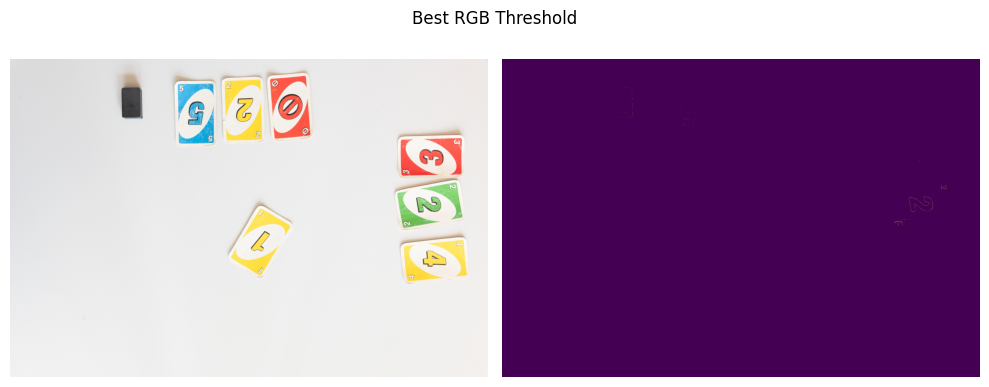

In [36]:
plot_thresholded_image(img=img, func=apply_rgb_threshold, title="Best RGB Threshold")

In [10]:
img_th=apply_rgb_threshold(img)